# Introduction

The goal of this notebook is to present the basic use of the "subset" command of the Copernicus Marine Toolbox. You can find more information about the use of this command [in the documentation](https://toolbox-docs.marine.copernicus.eu/en/stable/python-interface.html#copernicusmarine.subset).

## Import

We will need to import some specific packages to have this notebook running. They are grouped here.

In [6]:
from IPython.display import Video

In [7]:
import xarray as xr

In [8]:
import pandas as pd

## Installation

Normally the toolbox should be installed on the Jupyter Lab you are using. If it is not the case, you can install it via the following command:

In [9]:
!pip install copernicusmarine==2.5.0

And then you have to import it

In [10]:
import copernicusmarine

## Login

If you have already logged in a precedent step, this is not required. If not, you can use the following command and enter the username and password you have defined when you created your Copernicusmarine account

In [11]:
copernicusmarine.login()

INFO - 2026-10-01T07:59:07Z - Using existing credentials from /home/jovyan/.copernicusmarine/.copernicusmarine-credentials. Use --force-overwrite combined with credentials (specified by arguments, netrc file or environment variables) to always overwrite.


True

## Use of the subset command

The subset command is used to retrieve data from the data lake of Copernicus Marine, but only the specific parts you are interested in. Opposite to the get, the data are not the original data of the producers but data that have been divded into small chunks. We can for example gather data for a very small zone in the arctic for waves

In [12]:
copernicusmarine.subset(dataset_id="dataset-wam-arctic-1hr3km-be", variables=["VHM0_SW1"],
                        minimum_longitude=-62., maximum_longitude=-18.,
                        minimum_latitude=58., maximum_latitude=67.,
                        start_datetime="2026-09-30T12:00:00",
                        end_datetime="2026-10-01T12:00:00",)

INFO - 2026-10-01T07:59:12Z - Selected dataset version: "202411"
INFO - 2026-10-01T07:59:12Z - Selected dataset part: "default"
INFO - 2026-10-01T07:59:13Z - Total size of the download: 42.02 MB.


ResponseSubset(file_path=PosixPath('dataset-wam-arctic-1hr3km-be_VHM0_SW1_62.00W-18.02W_58.00N-66.97N_2026-09-30-2026-10-01.nc'), output_directory=PosixPath('.'), filename='dataset-wam-arctic-1hr3km-be_VHM0_SW1_62.00W-18.02W_58.00N-66.97N_2026-09-30-2026-10-01.nc', file_size=42.020954198473284, data_transfer_size=200.10992366412214, variables=['VHM0_SW1'], coordinates_extent=[GeographicalExtent(minimum=-61.99500000000002, maximum=-18.015000000000015, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=58.004999999999995, maximum=66.975, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2026-09-30T12:00:00+00:00', maximum='2026-10-01T12:00:00+00:00', unit='iso8601', coordinate_id='time')], status='000', message='The request was successful.', file_status='DOWNLOADED', file_names=None)

We can open the data found with xarray

In [13]:
wave_data = xr.open_dataset("dataset-wam-arctic-1hr3km-be_VHM0_SW1_62.00W-18.02W_58.00N-66.97N_2026-09-30-2026-10-01.nc")

In [14]:
wave_data

<xarray.Dataset> Size: 44MB
Dimensions:    (time: 25, latitude: 300, longitude: 1467)
Coordinates:
  * time       (time) datetime64[ns] 200B 2026-09-30T12:00:00 ... 2026-10-01T...
  * latitude   (latitude) float64 2kB 58.0 58.03 58.06 ... 66.91 66.94 66.97
  * longitude  (longitude) float64 12kB -62.0 -61.97 -61.94 ... -18.05 -18.02
Data variables:
    VHM0_SW1   (time, latitude, longitude) float32 44MB ...
Attributes:
    copernicusmarine_version:  2.5.0

And we can plot some data

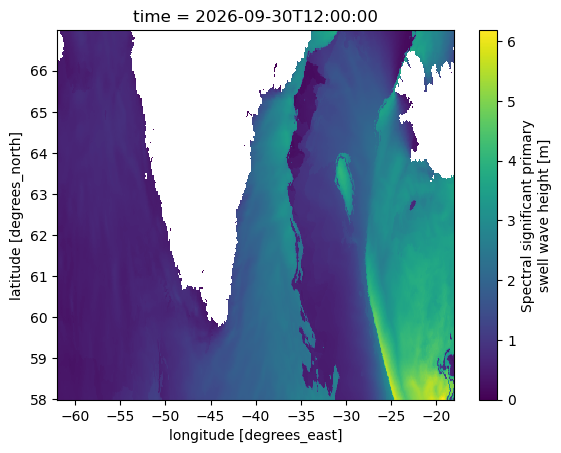

In [15]:
wave_data.isel(time=0).VHM0_SW1.plot()

### Practical steps

The easiest way to select correctly variables, time and zone of interest at first is probably by using the web interface of the catalogue. A demonstration of creation of a command is given in the video below

In [16]:
Video("videos/Steps_getting_command_subset.webm", width=1200, html_attributes="controls",embed=True)

### Exercise

Get the data for sea water salinity in the the monthly dataset of arctic physics for latitudes between 70-80° North and 50-70° East for longitudes for the year 2023 for depth from 0 to 200m.

### Answer

In [17]:
copernicusmarine.subset(dataset_id="cmems_mod_arc_phy_anfc_6km_detided_P1M-m",
                        variables=["so"], minimum_longitude=50,
                        maximum_longitude=70, minimum_latitude=70,
                        maximum_latitude=80, start_datetime="2023-01-01T00:00:00",
                        end_datetime="2024-01-01T00:00:00", minimum_depth=0,
                        maximum_depth=200,)

INFO - 2026-10-01T08:00:04Z - Selected dataset version: "202311"
INFO - 2026-10-01T08:00:04Z - Selected dataset part: "default"


  0%|          | [00:00<?]

INFO - 2026-10-01T08:00:07Z - Total size of the download: 39.96 MB.


ResponseSubset(file_path=PosixPath('cmems_mod_arc_phy_anfc_6km_detided_P1M-m_so_50.00E-69.92E_70.00N-80.00N_0.00-200.00m_2023-01-01-2024-01-01.nc'), output_directory=PosixPath('.'), filename='cmems_mod_arc_phy_anfc_6km_detided_P1M-m_so_50.00E-69.92E_70.00N-80.00N_0.00-200.00m_2023-01-01-2024-01-01.nc', file_size=39.95913740458015, data_transfer_size=234.1286106870229, variables=['so'], coordinates_extent=[GeographicalExtent(minimum=50.00000000003595, maximum=69.92000000003907, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=70.0, maximum=80.0, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2023-01-01T00:00:00+00:00', maximum='2024-01-01T00:00:00+00:00', unit='iso8601', coordinate_id='time'), GeographicalExtent(minimum=0.0, maximum=200.0, unit='m', coordinate_id='depth')], status='000', message='The request was successful.', file_status='DOWNLOADED', file_names=None)

In [18]:
salinity_data = xr.open_dataset("cmems_mod_arc_phy_anfc_6km_detided_P1M-m_so_50.00E-69.92E_70.00N-80.00N_0.00-200.00m_2023-01-01-2024-01-01.nc")

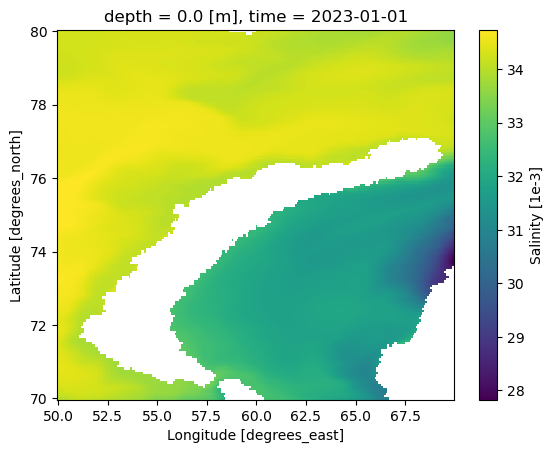

In [19]:
salinity_data.isel(time=0,depth=0).so.plot()

## Sparse data

You can also retrieve sparse data with the toolbox. The commands are the same but the data are retrieved in a slightly different format. Here is an example for drifter data in the Arctic.

In [36]:
copernicusmarine.subset(dataset_id="cmems_obs-ins_glo_phy-cur_my_drifter_PT1H",
                        variables=["EWCT", "NSCT"],
                        minimum_longitude=-80, maximum_longitude=80,
                        minimum_latitude=60., maximum_latitude=88.,
                        start_datetime="2026-01-29T23:00:00",
                        end_datetime="2026-01-30T23:00:00")

INFO - 2026-10-01T08:23:18Z - Selected dataset version: "202511"
INFO - 2026-10-01T08:23:18Z - Selected dataset part: "history"
100%|██████████| [00:00<00:00]


ResponseSubset(file_path=PosixPath('cmems_obs-ins_glo_phy-cur_my_drifter_PT1H_EWCT-NSCT_80.00W-80.00E_60.00N-88.00N_2026-01-29-2026-01-30_(2).csv'), output_directory=PosixPath('.'), filename='cmems_obs-ins_glo_phy-cur_my_drifter_PT1H_EWCT-NSCT_80.00W-80.00E_60.00N-88.00N_2026-01-29-2026-01-30_(2).csv', file_size=None, data_transfer_size=None, variables=['EWCT', 'NSCT'], coordinates_extent=[], status='000', message='The request was successful.', file_status='DOWNLOADED', file_names=None)

In [21]:
dataset_insitu = pd.read_csv("cmems_obs-ins_glo_phy-cur_my_drifter_PT1H_EWCT-NSCT_80.00W-80.00E_60.00N-88.00N_2026-01-29-2026-01-30.csv")

In [22]:
dataset_insitu

,variable,platform_id,platform_type,time,longitude,latitude,depth,pressure,is_depth_from_producer,value,value_qc,institution,doi,product_doi
0,EWCT,2802100,DC,2026-01-29T23:00:00Z,-0.467529,70.82251,15.0,NaN,1,0.0882,1,Lagrangian Drifter Laboratory,https://doi.org/10.17882/86236,https://doi.org/10.17882/86236
1,EWCT,2802100,DC,2026-01-30T00:00:00Z,-0.456970,70.82925,15.0,NaN,1,0.1226,1,Lagrangian Drifter Laboratory,https://doi.org/10.17882/86236,https://doi.org/10.17882/86236
2,EWCT,2802100,DC,2026-01-30T01:00:00Z,-0.441895,70.83712,0.5,NaN,1,0.1823,1,Lagrangian Drifter Laboratory,https://doi.org/10.17882/86236,https://doi.org/10.17882/86236
3,EWCT,2802100,DC,2026-01-30T02:00:00Z,-0.419983,70.84548,0.5,NaN,1,0.2595,1,Lagrangian Drifter Laboratory,https://doi.org/10.17882/86236,https://doi.org/10.17882/86236
4,EWCT,2802100,DC,2026-01-30T03:00:00Z,-0.390747,70.85333,0.5,NaN,1,0.3348,1,Lagrangian Drifter Laboratory,https://doi.org/10.17882/86236,https://doi.org/10.17882/86236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
545,NSCT,6801907,DC,2026-01-30T19:00:00Z,-4.018066,67.87462,0.5,NaN,1,0.0378,1,Lagrangian Drifter Laboratory,https://doi.org/10.17882/86236,https://doi.org/10.17882/86236
546,NSCT,6801907,DC,2026-01-30T20:00:00Z,-4.009521,67.87594,0.5,NaN,1,0.0403,1,Lagrangian Drifter Laboratory,https://doi.org/10.17882/86236,https://doi.org/10.17882/86236
547,NSCT,6801907,DC,2026-01-30T21:00:00Z,-4.002319,67.87745,0.5,NaN,1,0.0546,1,Lagrangian Drifter Laboratory,https://doi.org/10.17882/86236,https://doi.org/10.17882/86236
548,NSCT,6801907,DC,2026-01-30T22:00:00Z,-3.994507,67.87977,0.5,NaN,1,0.0841,1,Lagrangian Drifter Laboratory,https://doi.org/10.17882/86236,https://doi.org/10.17882/86236


You can also retrieve data in Netcdf with a small command modification. It will create one NetCDF per platform.

In [37]:
copernicusmarine.subset(dataset_id="cmems_obs-ins_glo_phy-cur_my_drifter_PT1H",
                        variables=["EWCT", "NSCT"],
                        minimum_longitude=-80, maximum_longitude=80,
                        minimum_latitude=60., maximum_latitude=88.,
                        start_datetime="2026-01-29T23:00:00",
                        end_datetime="2026-01-30T23:00:00",
                        file_format="netcdf")

INFO - 2026-10-01T08:23:35Z - Selected dataset version: "202511"
INFO - 2026-10-01T08:23:35Z - Selected dataset part: "history"
100%|██████████| [00:00<00:00]
INFO - 2026-10-01T08:23:36Z - Produced 11 NetCDF file(s) in cmems_obs-ins_glo_phy-cur_my_drifter_PT1H_EWCT-NSCT_80.00W-80.00E_60.00N-88.00N_2026-01-29-2026-01-30_(1)


ResponseSubset(file_path=PosixPath('cmems_obs-ins_glo_phy-cur_my_drifter_PT1H_EWCT-NSCT_80.00W-80.00E_60.00N-88.00N_2026-01-29-2026-01-30_(1)'), output_directory=PosixPath('.'), filename='cmems_obs-ins_glo_phy-cur_my_drifter_PT1H_EWCT-NSCT_80.00W-80.00E_60.00N-88.00N_2026-01-29-2026-01-30_(1)', file_size=None, data_transfer_size=None, variables=['EWCT', 'NSCT'], coordinates_extent=[], status='000', message='The request was successful.', file_status='DOWNLOADED', file_names=['2802100.nc', '3801575.nc', '4402749.nc', '5801978.nc', '6203831.nc', '6203834.nc', '6203836.nc', '6203853.nc', '6203854.nc', '6402739.nc', '6801907.nc'])

In [38]:
insitu_data_in_xarray = xr.open_mfdataset("cmems_obs-ins_glo_phy-cur_my_drifter_PT1H_EWCT-NSCT_80.00W-80.00E_60.00N-88.00N_2026-01-29-2026-01-30/6203836.nc")

In [39]:
insitu_data_in_xarray

<xarray.Dataset> Size: 2kB
Dimensions:    (time: 25, depth_level: 1)
Coordinates:
  * time       (time) datetime64[ns] 200B 2026-01-29T23:00:00 ... 2026-01-30T...
    depth      (time, depth_level) float64 200B dask.array<chunksize=(25, 1), meta=np.ndarray>
    longitude  (time, depth_level) float64 200B dask.array<chunksize=(25, 1), meta=np.ndarray>
    latitude   (time, depth_level) float64 200B dask.array<chunksize=(25, 1), meta=np.ndarray>
Dimensions without coordinates: depth_level
Data variables:
    EWCT       (time, depth_level) float64 200B dask.array<chunksize=(25, 1), meta=np.ndarray>
    NSCT       (time, depth_level) float64 200B dask.array<chunksize=(25, 1), meta=np.ndarray>
    EWCT_QC    (time, depth_level) int64 200B dask.array<chunksize=(25, 1), meta=np.ndarray>
    NSCT_QC    (time, depth_level) int64 200B dask.array<chunksize=(25, 1), meta=np.ndarray>
Attributes: (12/26)
    platform_code:                     6203836
    platform_type:                     DC
    institution:                       Lagrangian Drifter Laboratory
    doi:                               https://doi.org/10.17882/86236 https:/...
    institution_edmo_code:             6044
    time_coverage_start:               2026-01-29T23:00:00Z
    ...                                ...
    product_id:                        INSITU_GLO_PHY_UV_DISCRETE_MY_013_044
    dataset_id:                        cmems_obs-ins_glo_phy-cur_my_drifter_PT1H
    Conventions:                       CF-1.9 ACDD-1.3
    title:                             Subset of dataset cmems_obs-ins_glo_ph...
    contact:                           servicedesk.cmems@mercator-ocean.eu
    history:                           2026-10-01T08:07:10.266946: Subset fro...

### Exercise

Download data for gliders in the North Atlantic Ocean ( N:60, S:20, W: -90, E:0) for the month of october 2023 for seawater speed and seawater temperature for depth until 1500m

In [40]:
copernicusmarine.subset(dataset_id="cmems_obs-ins_glo_phy-cur_my_adcp_irr",
                        variables=["HCSP", "TEMP"], minimum_longitude=-90.,
                        maximum_longitude=0., minimum_latitude=20.,
                        maximum_latitude=60., start_datetime="2023-10-01T00:00:00",
                        end_datetime="2023-10-30T23:59:02", maximum_depth=1500,
                       )

INFO - 2026-10-01T08:24:23Z - Selected dataset version: "202511"
INFO - 2026-10-01T08:24:23Z - Selected dataset part: "history"
100%|██████████| [01:37<00:00]


ResponseSubset(file_path=PosixPath('cmems_obs-ins_glo_phy-cur_my_adcp_irr_HCSP-TEMP_90.00W-0.00E_20.00N-60.00N_2023-10-01-2023-10-30.csv'), output_directory=PosixPath('.'), filename='cmems_obs-ins_glo_phy-cur_my_adcp_irr_HCSP-TEMP_90.00W-0.00E_20.00N-60.00N_2023-10-01-2023-10-30.csv', file_size=None, data_transfer_size=None, variables=['HCSP', 'TEMP'], coordinates_extent=[], status='000', message='The request was successful.', file_status='DOWNLOADED', file_names=None)

In [41]:
glider_dataset = pd.read_csv("cmems_obs-ins_glo_phy-cur_my_adcp_irr_HCSP-TEMP_90.00W-0.00E_20.00N-60.00N_2023-10-01-2023-10-30.csv")

In [42]:
glider_dataset

,variable,platform_id,platform_type,time,longitude,latitude,depth,pressure,is_depth_from_producer,value,value_qc,institution,doi,product_doi
0,HCSP,6200085,MO,2023-10-01T00:00:00Z,-6.96,36.49,56.0,NaN,1,0.148,1,Puertos del Estado,https://doi.org/10.17882/86236,https://doi.org/10.17882/86236
1,HCSP,6200085,MO,2023-10-01T00:00:00Z,-6.96,36.49,80.0,NaN,1,0.070,1,Puertos del Estado,https://doi.org/10.17882/86236,https://doi.org/10.17882/86236
2,HCSP,6200085,MO,2023-10-01T00:00:00Z,-6.96,36.49,72.0,NaN,1,0.102,1,Puertos del Estado,https://doi.org/10.17882/86236,https://doi.org/10.17882/86236
3,HCSP,6200085,MO,2023-10-01T00:00:00Z,-6.96,36.49,16.0,NaN,1,0.098,1,Puertos del Estado,https://doi.org/10.17882/86236,https://doi.org/10.17882/86236
4,HCSP,6200085,MO,2023-10-01T00:00:00Z,-6.96,36.49,6.0,NaN,1,0.086,1,Puertos del Estado,https://doi.org/10.17882/86236,https://doi.org/10.17882/86236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10682,HCSP,6200085,MO,2023-10-30T23:00:00Z,-6.96,36.49,48.0,NaN,1,0.172,1,Puertos del Estado,https://doi.org/10.17882/86236,https://doi.org/10.17882/86236
10683,HCSP,6200085,MO,2023-10-30T23:00:00Z,-6.96,36.49,96.0,NaN,1,0.027,1,Puertos del Estado,https://doi.org/10.17882/86236,https://doi.org/10.17882/86236
10684,HCSP,6200085,MO,2023-10-30T23:00:00Z,-6.96,36.49,120.0,NaN,1,0.027,1,Puertos del Estado,https://doi.org/10.17882/86236,https://doi.org/10.17882/86236
10685,HCSP,6200085,MO,2023-10-30T23:00:00Z,-6.96,36.49,6.0,NaN,1,0.215,1,Puertos del Estado,https://doi.org/10.17882/86236,https://doi.org/10.17882/86236


### Satellite data

The subset can also be used to retrieve satellite data for long time series in a given zone for example. We can look at the zone:

In [43]:
copernicusmarine.subset(dataset_id="cmems_sat-si_glo_drift_nrt_north_d",
                        minimum_longitude=-116., maximum_longitude=177.,
                        minimum_latitude=49., maximum_latitude=83.,
                        start_datetime="2026-09-30T12:00:00",
                        end_datetime="2026-09-30T12:00:00")

INFO - 2026-10-01T08:36:47Z - Selected dataset version: "202007"
INFO - 2026-10-01T08:36:47Z - Selected dataset part: "default"


  0%|          | [00:00<?]

INFO - 2026-10-01T08:36:49Z - Total size of the download: 45.80 MB.


ResponseSubset(file_path=PosixPath('cmems_sat-si_glo_drift_nrt_north_d_multi-vars_115.90W-177.00E_49.00N-83.00N_2026-09-30.nc'), output_directory=PosixPath('.'), filename='cmems_sat-si_glo_drift_nrt_north_d_multi-vars_115.90W-177.00E_49.00N-83.00N_2026-09-30.nc', file_size=45.799706106870225, data_transfer_size=120.06598473282442, variables=['dXY_count', 'dX_mean', 'dX_std', 'dY_mean', 'dY_std', 'divergence', 'qos_mean_dX', 'qos_mean_dY', 'qos_sample_count', 'qos_stddev_dX', 'qos_stddev_dY', 'shear', 'status_flag', 'time_first', 'time_last', 'time_period_end', 'time_period_start', 'vorticity'], coordinates_extent=[GeographicalExtent(minimum=-115.90000000000364, maximum=176.9999999999797, unit='degrees_east', coordinate_id='longitude'), GeographicalExtent(minimum=49.0, maximum=83.0, unit='degrees_north', coordinate_id='latitude'), TimeExtent(minimum='2026-09-30T12:00:00+00:00', maximum='2026-09-30T12:00:00+00:00', unit='iso8601', coordinate_id='time')], status='000', message='The reques

In [44]:
satellite_data = xr.open_dataset("cmems_sat-si_glo_drift_nrt_north_d_multi-vars_115.90W-177.00E_49.00N-83.00N_2026-09-30.nc")

In [45]:
satellite_data

<xarray.Dataset> Size: 48MB
Dimensions:            (time: 1, latitude: 341, longitude: 2930)
Coordinates:
  * time               (time) datetime64[ns] 8B 2026-09-30T12:00:00
  * latitude           (latitude) float64 3kB 49.0 49.1 49.2 ... 82.8 82.9 83.0
  * longitude          (longitude) float64 23kB -115.9 -115.8 ... 176.9 177.0
Data variables: (12/18)
    dXY_count          (time, latitude, longitude) float32 4MB ...
    dX_mean            (time, latitude, longitude) float32 4MB ...
    dX_std             (time, latitude, longitude) float32 4MB ...
    dY_mean            (time, latitude, longitude) float32 4MB ...
    dY_std             (time, latitude, longitude) float32 4MB ...
    divergence         (time, latitude, longitude) float32 4MB ...
    ...                 ...
    status_flag        (time) int16 2B ...
    time_first         (time, latitude, longitude) float64 8MB ...
    time_last          (time, latitude, longitude) float64 8MB ...
    time_period_end    (time) float64 8B ...
    time_period_start  (time) float64 8B ...
    vorticity          (time, latitude, longitude) float32 4MB ...
Attributes: (12/21)
    Conventions:               CF-1.6
    PI_name:                   Roberto Saldo
    abstract:                  Mean/standard deviation and divergence/vortici...
    activity_type:             space borne instrument
    area:                      northern hemisphere
    contact:                   rs@space.dtu.dk
    ...                        ...
    software_version:          v20200826b
    start_date:                2025-01-08 12:00:00 UTC
    stop_date:                 2025-01-09 12:00:00 UTC
    title:                     Arctic Sea Ice Drift, L4 SAR, 10km daily
    topiccategory:             Oceans ClimatologyMeteorologyAtmosphere
    copernicusmarine_version:  2.5.0

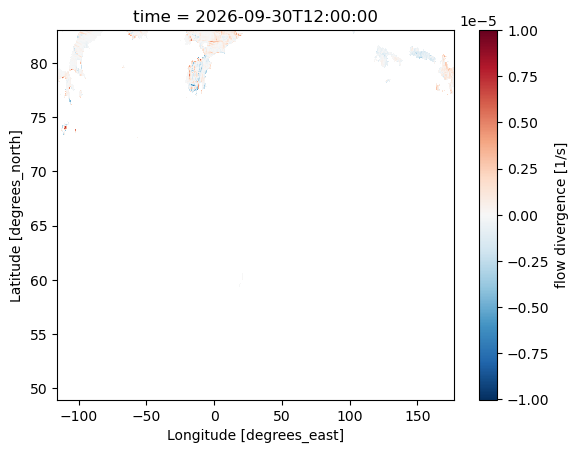

In [46]:
satellite_data.isel(time=0).divergence.plot()